


# Projeto de Matemática para Ciência de Dados — Rede Neural

Base: `exemplo4.py` (aula 21/08/2026). Entrega: 26/09/2026.

A ideia é pegar a rede do `exemplo4.py` e generalizar ela: em vez de escrever uma linha de código pra
cada neurônio, escrevemos a mesma conta usando matrizes, aí dá pra usar quantas camadas e neurônios a
gente quiser.

O que mudou em relação ao original:

| | `exemplo4.py` | Aqui |
|---|---|---|
| Base de dados | make_moons | make_blobs (desbalanceada de propósito) |
| Camadas ocultas | 1 | 3 |
| Neurônios | 2 → 1 | 8 → 6 → 4 → 1 |
| Ativação das ocultas | Sigmoide | ReLU |
| Ativação da saída | Sigmoide | Sigmoide |
| Função de perda | Erro quadrático | Entropia cruzada |

O `make_blobs` gera 3 grupos de pontos e a gente junta 2 deles numa classe só, então uma classe fica com
o dobro de exemplos da outra — fica mais parecido com dado real, que quase nunca vem bem dividido.
Usamos ReLU nas camadas escondidas porque com sigmoide numa rede mais funda o gradiente vai sumindo aos
poucos (o tal *vanishing gradient*). A saída continua sigmoide porque a gente precisa de uma
probabilidade entre 0 e 1. E trocamos a função de perda pra entropia cruzada, que combina melhor com
essa saída sigmoide (a Seção 5 explica o porquê).

No final comparamos com uma rede equivalente feita no Keras, pra validar se a implementação manual está
certa.

## 0. Instalando as bibliotecas

Rode esta célula primeiro, uma única vez. Ela instala as bibliotecas no mesmo ambiente Python que o
Jupyter está usando agora — isso evita o erro `ModuleNotFoundError`, que costuma acontecer quando o
pacote foi instalado num Python diferente do que o notebook está rodando (por exemplo, pelo terminal,
mas com o VS Code usando outro interpretador). Se todas já estiverem instaladas, a célula só vai
mostrar "Requirement already satisfied" e não faz nada de mais.

In [1]:
%pip install -q numpy matplotlib scikit-learn tensorflow

Note: you may need to restart the kernel to use updated packages.


## 1. Base de dados

A base de dados utilizada foi gerada pela função make_blobs,da biblioteca Scikit-learn, que gera  aglomerados (blobs) de pontos distribuidos de forma gaussiana. Essa base serve principalmente para testar e demonstrar algoritmos de aprendizado de máquina voltados para agrupamento (clustering, como o K-Means) e classificação.

Com o objetivo de criar um cenário mais desafiador e próximo da complexidade de dados reais, a base de dados foi configurada com 1000 amostras e um desvio padrão elevado. Isso torna os dados mais dispersos ao redor do cluster e, consequentemente, mais misturados e sobrepostos uns aos outros. O resultado é um conjunto de dados mais realista e, ao mesmo tempo, difícil para algoritmos de aprendizado de máquina identificarem divisões exatas entre as classes.

Além disso, a estrutura original do problema, que era multinomial, foi convertida em problema de classificação binária, mapeando a classe 0 como **classe positiva**, enquanto as classes 1 e 2 foram agrupadas para representar a **classe negativa**. A respectiva fusão tornou esse conjunto de dados desbalanceado, pois a classe negativa passou a concentrar o dobro de instâncias em relação á classe positiva, e, consequentemente, eleva o rigor dos testes, exigindo maior robustez dos modelos avaliados.

Total Positivo: 334
Total Negativo: 666


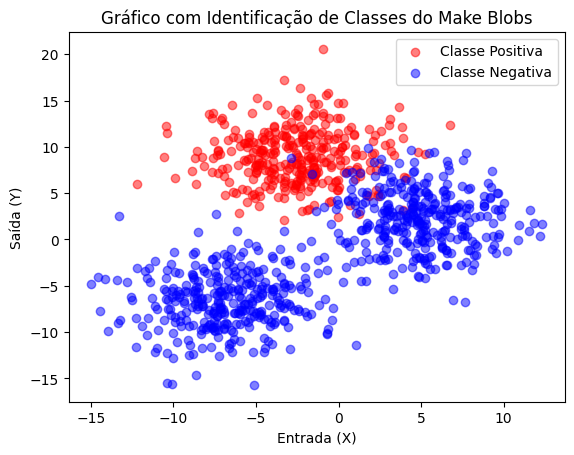

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# 1. Gerar os dados
X, Y = make_blobs(n_samples=1000, centers=3, n_features=2, random_state=42, cluster_std=3.0)

# 2. Binarização: 1 se for classe 0; 0 caso contrário
Y = np.where(Y == 0, 1, 0)

# Configurações do gráfico
plt.title('Gráfico com Identificação de Classes do Make Blobs')
plt.xlabel('Entrada (X)')
plt.ylabel('Saída (Y)')

# 3. Separar e plotar a Classe Negativa (Y == 0)
plt.scatter(
    X[Y == 1, 0], X[Y == 1, 1], 
    label='Classe Positiva', c='red', alpha=0.5
)

# 4. Separar e plotar a Classe Positiva (Y == 1)
plt.scatter(
    X[Y == 0, 0], X[Y == 0, 1], 
    label='Classe Negativa', c='blue', alpha=0.5
)

# 5. legenda
plt.legend(loc='upper right')

# Exibir os prints e o gráfico
print("Total Positivo:", np.sum(Y == 1))
print("Total Negativo:", np.sum(Y == 0))
plt.show()

## 2. Funções de ativação

- **Sigmoide**: $\sigma(v) = \dfrac{1}{1+e^{-v}}$, com derivada $\sigma'(v) = \sigma(v)(1-\sigma(v))$ — usada
  só na saída, porque comprime o resultado entre 0 e 1 (interpretável como probabilidade).
- **ReLU**: $\text{ReLU}(v) = \max(0, v)$, com derivada $1$ se $v>0$ e $0$ caso contrário — usada nas 3
  camadas escondidas, porque sua derivada não encolhe para entradas positivas, evitando o vanishing
  gradient numa rede mais profunda que a original.

In [3]:
def sigmoide(v):
    return 1 / (1 + np.exp(-v))

def sigmoide_deriv(v):
    s = sigmoide(v)
    return s * (1 - s)

def relu(v):
    return np.maximum(0, v)

def relu_deriv(v):
    return (v > 0).astype(float)

print('sigmoide(0) =', sigmoide(0), '  relu(-2) =', relu(-2), '  relu(3) =', relu(3))

sigmoide(0) = 0.5   relu(-2) = 0   relu(3) = 3


## 3. Arquitetura generalizada em matrizes

Para uma rede com $N$ camadas, definimos $\mathbf{a}^{(0)} = \mathbf{x}$ e, para cada camada
$l=1,\dots,N$:

$$\mathbf{v}^{(l)} = W^{(l)}\mathbf{a}^{(l-1)} + \mathbf{b}^{(l)} \qquad \mathbf{a}^{(l)} = \sigma^{(l)}(\mathbf{v}^{(l)})$$

Isso é o mesmo cálculo do `exemplo4.py` (que escrevia `s00 = w0[0,0]*x[0]`, `s01 = w0[0,1]*x[1]`,
`v0 = s00+s01+b0[0]` linha por linha para cada neurônio), só que a matriz $W^{(l)}$ faz todas essas
multiplicações e somas de uma vez, para qualquer número de neurônios.

Nossa arquitetura é $[2, 8, 6, 4, 1]$: 2 entradas, três camadas escondidas (8, 6, 4 neurônios), 1 saída.
Em código (com exemplos em linha, não em coluna), cada $W^{(l)}$ tem forma `(tamanhos[l], tamanhos[l+1])`.

In [4]:
def inicializar_pesos(tamanhos, seed=0):
    rng = np.random.RandomState(seed)
    L = len(tamanhos) - 1
    W = [rng.randn(tamanhos[i], tamanhos[i+1]) * 0.5 for i in range(L)]
    b = [np.zeros(tamanhos[i+1]) for i in range(L)]
    return W, b

tamanhos = [2, 8, 6, 4, 1]
W, b = inicializar_pesos(tamanhos, seed=0)
for i, (Wi, bi) in enumerate(zip(W, b)):
    print(f'camada {i+1}: W{i+1}.shape = {Wi.shape}   b{i+1}.shape = {bi.shape}')

camada 1: W1.shape = (2, 8)   b1.shape = (8,)
camada 2: W2.shape = (8, 6)   b2.shape = (6,)
camada 3: W3.shape = (6, 4)   b3.shape = (4,)
camada 4: W4.shape = (4, 1)   b4.shape = (1,)


## 4. Forward pass generalizado

Um laço `for` percorre as camadas — nenhuma é tratada como caso especial. As três primeiras usam ReLU,
a última usa sigmoide.

In [5]:
ativ = [relu, relu, relu, sigmoide]
ativ_deriv = [relu_deriv, relu_deriv, relu_deriv, sigmoide_deriv]

def forward(X, W, b):
    a = X
    cache_v, cache_a = [], [a]
    for l in range(len(W)):
        v = a @ W[l] + b[l]
        a = ativ[l](v)
        cache_v.append(v)
        cache_a.append(a)
    return a, cache_v, cache_a

yhat, cache_v, cache_a = forward(X, W, b)
print('formato da saida:', yhat.shape)
print('primeiras 5 predicoes (pesos ainda aleatorios):', yhat[:5].ravel())

formato da saida: (1000, 1)
primeiras 5 predicoes (pesos ainda aleatorios): [0.5341413  0.52630315 0.5        0.49762911 0.4977047 ]


## 5. Função de perda

O `exemplo4.py` usa erro quadrático (`L = 1/2 * (e ** 2)`). O problema é que, com saída sigmoide, isso
trava o treino: a derivada dá $(\hat y - y)\,\hat y(1-\hat y)$, e esse fator $\hat y(1-\hat y)$ vai quase
a zero bem na hora em que a rede erra com confiança — ou seja, justo quando mais precisava aprender, o
gradiente quase some. Por isso trocamos pela entropia cruzada binária:

$$L = -\frac{1}{n}\sum_{i=1}^{n}\Big[\,y_i\ln \hat y_i + (1-y_i)\ln(1-\hat y_i)\,\Big]$$

Guardamos aqui que a derivada dela em relação a $\hat y$ também tem um $\hat y(1-\hat y)$ no
denominador — isso importa porque, na Seção 6, esse termo cancela com a derivada da sigmoide.

Dois cuidados no código:

- Se a sigmoide saturar em `0.0` ou `1.0`, o `ln` dá `-infinito` e a perda vira `nan`. Por isso limitamos
  $\hat y$ pra não chegar exatamente em 0 ou 1.
- `Y` precisa estar em formato coluna `(n, 1)`, não `(n,)` — senão o NumPy faz um broadcasting errado sem
  avisar (vira uma matriz `(n, n)` em vez de dar erro) e o treino roda inteiro calculando besteira.

Outra diferença: o original soma o gradiente dos 100 exemplos, aqui a gente tira a média. É a mesma
direção, só que o passo fica $n$ vezes menor — por isso a `taxa` de lá não dá pra comparar direto com a
nossa.

In [6]:
# Y vira matriz coluna (n, 1) para casar com o formato de yhat e evitar broadcasting silencioso
Y = Y.reshape(-1, 1).astype(float)

EPS = 1e-12  # margem que impede ln(0)

def perda(Y, Yhat):
    """Entropia cruzada binaria media: -1/n * sum[ y*ln(yhat) + (1-y)*ln(1-yhat) ]."""
    Yhat = np.clip(Yhat, EPS, 1 - EPS)
    return -np.mean(Y * np.log(Yhat) + (1 - Y) * np.log(1 - Yhat))


def acuracia(Y, Yhat):
    """Fracao de acertos, usando 0.5 como limiar de decisao."""
    return np.mean((Yhat >= 0.5).astype(float) == Y)


# Sanidade: com os pesos ainda aleatorios a rede nao sabe nada, entao a perda
# deve ficar perto de ln(2) ~ 0.693 -- o valor de quem "chuta" 0.5 para todo mundo.
yhat, cache_v, cache_a = forward(X, W, b)

print(f'Y.shape = {Y.shape}   yhat.shape = {yhat.shape}')
print(f'perda inicial = {perda(Y, yhat):.4f}   (referencia do chute: ln(2) = {np.log(2):.4f})')
print(f'acuracia inicial = {acuracia(Y, yhat):.4f}')

# Os dois casos extremos, para ver a assimetria da entropia cruzada:
print(f'\nacerto confiante  (y=1, yhat=0.99): perda = {perda(np.array([[1.0]]), np.array([[0.99]])):.4f}')
print(f'erro   confiante  (y=1, yhat=0.01): perda = {perda(np.array([[1.0]]), np.array([[0.01]])):.4f}')

Y.shape = (1000, 1)   yhat.shape = (1000, 1)
perda inicial = 0.7284   (referencia do chute: ln(2) = 0.6931)
acuracia inicial = 0.2100

acerto confiante  (y=1, yhat=0.99): perda = 0.0101
erro   confiante  (y=1, yhat=0.01): perda = 4.6052


## 6. Backward generalizado

É a mesma regra da cadeia do `exemplo4.py` (lá escrita variável por variável, tipo `grad_s00`,
`grad_w0[0,0]`), só que agora funciona pra qualquer número de camadas de uma vez. A peça principal é o
$\delta^{(l)}$: o erro que chega na entrada da camada $l$. Com ele em mãos, os gradientes saem direto:

$$\frac{\partial L}{\partial W^{(l)}} = \big(A^{(l-1)}\big)^{\!\top} \Delta^{(l)}
\qquad
\frac{\partial L}{\partial \mathbf{b}^{(l)}} = \sum_{i=1}^{n} \Delta^{(l)}_{i,:}$$

(as letras maiúsculas são os $n$ exemplos empilhados; o viés soma sobre os exemplos porque é o mesmo pra
todo mundo.)

Na última camada, a derivada da perda encontra a da sigmoide e um termo cancela o outro:

$$\delta^{(N)} = \underbrace{\frac{1}{n}\cdot\frac{\hat y - y}{\hat y(1-\hat y)}}_{\text{perda}}\cdot\underbrace{\hat y(1-\hat y)}_{\sigma'(v^{(N)})} = \frac{\hat y - y}{n}$$

Sobra só o erro puro, sem nada que possa saturar — é exatamente pra isso que serve a entropia cruzada.
Daí pra trás, camada por camada:

$$\delta^{(l)} = \Big(\delta^{(l+1)}\,\big(W^{(l+1)}\big)^{\!\top}\Big)\;\odot\;\sigma^{(l)\prime}\!\big(v^{(l)}\big)$$

$W^\top$ manda o erro de volta pelas mesmas ligações do forward (só que transposta), e o $\odot$
(multiplicação termo a termo) filtra pelo quanto cada neurônio reagiu — com ReLU, quem tava desligado
não recebe gradiente nenhum.

Um detalhe de índice pra não se perder: `cache_a[l]` é $a^{(l)}$, mas `cache_v[l]` guarda $v^{(l+1)}$ —
tá deslocado em 1. No código, o índice `l` do laço corresponde à camada $l+1$ da matemática.

In [7]:
def backward(Y, W, b, cache_v, cache_a):
    """Gradientes da entropia cruzada em relacao a W e b, para qualquer numero de camadas.

    Devolve (gW, gb), com gW[l].shape == W[l].shape e gb[l].shape == b[l].shape.
    """
    L = len(W)                  # numero de camadas
    n = Y.shape[0]              # numero de exemplos
    gW = [None] * L
    gb = [None] * L

    Yhat = cache_a[-1]          # saida do forward = a^(N)

    # Passo 1: delta da ultima camada.
    # O denominador yhat(1-yhat) da derivada da entropia cruzada cancela com
    # sigmoide_deriv, sobrando o erro puro. Dividimos por n porque a perda e a media.
    delta = (Yhat - Y) / n

    # Passo 2: percorre as camadas de tras para frente.
    for l in reversed(range(L)):
        # Gradientes desta camada, usando o delta que ja chegou aqui.
        gW[l] = cache_a[l].T @ delta        # (tam[l], n) @ (n, tam[l+1])
        gb[l] = delta.sum(axis=0)           # soma sobre os exemplos

        # Propaga o delta para a camada anterior (nao ha o que propagar antes da 1a).
        if l > 0:
            erro_redistribuido = delta @ W[l].T          # volta pela matriz transposta
            delta = erro_redistribuido * ativ_deriv[l - 1](cache_v[l - 1])  # filtra (Hadamard)

    return gW, gb


# Teste de formato: e o jeito mais barato de pegar erro de transposicao.
yhat, cache_v, cache_a = forward(X, W, b)
gW, gb = backward(Y, W, b, cache_v, cache_a)

for l in range(len(W)):
    ok_W = gW[l].shape == W[l].shape
    ok_b = gb[l].shape == b[l].shape
    print(f'camada {l+1}: gW{l+1} {gW[l].shape} vs W{l+1} {W[l].shape} -> {ok_W}   |   '
          f'gb{l+1} {gb[l].shape} vs b{l+1} {b[l].shape} -> {ok_b}')

assert all(gW[l].shape == W[l].shape for l in range(len(W)))
assert all(gb[l].shape == b[l].shape for l in range(len(b)))
print('\nTodos os formatos batem.')

camada 1: gW1 (2, 8) vs W1 (2, 8) -> True   |   gb1 (8,) vs b1 (8,) -> True
camada 2: gW2 (8, 6) vs W2 (8, 6) -> True   |   gb2 (6,) vs b2 (6,) -> True
camada 3: gW3 (6, 4) vs W3 (6, 4) -> True   |   gb3 (4,) vs b3 (4,) -> True
camada 4: gW4 (4, 1) vs W4 (4, 1) -> True   |   gb4 (1,) vs b4 (1,) -> True

Todos os formatos batem.


## 7. Verificação numérica do gradiente

Só os formatos baterem não prova nada — um sinal trocado passa despercebido e a rede simplesmente treina
mal. O teste de verdade é comparar cada gradiente do `backward` com a diferença central (que vem de duas
expansões de Taylor, onde o termo do meio se cancela):

$$\frac{\partial L}{\partial \theta} \approx \frac{L(\theta+\varepsilon) - L(\theta-\varepsilon)}{2\varepsilon}
\qquad
\text{erro} = \frac{|\,g_{\text{analítico}} - g_{\text{numérico}}\,|}{|g_{\text{analítico}}| + |g_{\text{numérico}}|}$$

Erro abaixo de $10^{-7}$ é considerado correto. Esse método é caro demais pra usar no treino de verdade
(avalia a rede inteira duas vezes por parâmetro) — é por isso que existe o backpropagation.

O teste principal roda numa rede pequena só com sigmoide, porque a ReLU não é derivável exatamente em
$v=0$: ao somar o $\varepsilon$, alguns exemplos cruzam essa quina e o numérico enxerga um salto que o
analítico não vê. Repetimos o teste na rede real também, só pra confirmar que quem discorda são os
parâmetros que caem bem na quina — não é bug.

In [8]:
def gradiente_numerico(param, idx, Xd, Yd, Wd, bd, eps=1e-5):
    """Derivada de L em relacao a param[idx], pela diferenca central."""
    original = param[idx]
    param[idx] = original + eps
    L_mais = perda(Yd, forward(Xd, Wd, bd)[0])
    param[idx] = original - eps
    L_menos = perda(Yd, forward(Xd, Wd, bd)[0])
    param[idx] = original                       # desfaz a perturbacao
    return (L_mais - L_menos) / (2 * eps)


def verificar_gradiente(Xd, Yd, Wd, bd):
    """Compara backward vs diferenca central em TODOS os parametros. Devolve os erros relativos."""
    _, cv, ca = forward(Xd, Wd, bd)
    gWd, gbd = backward(Yd, Wd, bd, cv, ca)

    erros = []
    for l in range(len(Wd)):
        for i in range(Wd[l].shape[0]):
            for j in range(Wd[l].shape[1]):
                ana = gWd[l][i, j]
                num = gradiente_numerico(Wd[l], (i, j), Xd, Yd, Wd, bd)
                erros.append(abs(ana - num) / max(1e-12, abs(ana) + abs(num)))
        for j in range(bd[l].shape[0]):
            ana = gbd[l][j]
            num = gradiente_numerico(bd[l], (j,), Xd, Yd, Wd, bd)
            erros.append(abs(ana - num) / max(1e-12, abs(ana) + abs(num)))
    return np.array(erros)


# --- Teste 1: rede pequena e lisa (sigmoide em todas as camadas) ---
# E aqui que o backward e de fato validado: a funcao e derivavel em todo ponto,
# entao qualquer discrepancia acima de 1e-7 seria erro de matematica.
rng = np.random.RandomState(7)
X_teste = rng.randn(20, 3)
Y_teste = rng.randint(0, 2, (20, 1)).astype(float)
W_teste, b_teste = inicializar_pesos([3, 5, 4, 1], seed=3)

ativ_original, ativ_deriv_original = ativ, ativ_deriv
try:
    ativ = [sigmoide] * 3                    # troca temporaria: rede lisa
    ativ_deriv = [sigmoide_deriv] * 3
    erros_lisa = verificar_gradiente(X_teste, Y_teste, W_teste, b_teste)
finally:
    ativ, ativ_deriv = ativ_original, ativ_deriv_original   # restaura a rede real

print(f'Teste 1 - rede lisa [3,5,4,1], {len(erros_lisa)} parametros')
print(f'  erro relativo maximo: {erros_lisa.max():.3e}')
print(f'  erro relativo medio : {erros_lisa.mean():.3e}')
print('  ->', 'BACKWARD CORRETO' if erros_lisa.max() < 1e-7 else 'HA ALGO ERRADO')

# --- Teste 2: a rede real, com ReLU ---
# Aqui o maximo NAO e a metrica certa: a quina da ReLU em v=0 faz alguns parametros
# discordarem por construcao. Olhamos a mediana e a fracao dentro da tolerancia.
erros_relu = verificar_gradiente(X, Y, W, b)
n_fora = int(np.sum(erros_relu >= 1e-7))

print(f'\nTeste 2 - rede real {tamanhos} com ReLU, {len(erros_relu)} parametros')
print(f'  mediana do erro relativo: {np.median(erros_relu):.3e}')
print(f'  dentro de 1e-7          : {len(erros_relu) - n_fora}/{len(erros_relu)} '
      f'({100*(1 - n_fora/len(erros_relu)):.1f}%)')
print(f'  fora                    : {n_fora} parametros que caem na quina da ReLU,')
print('                             onde a derivada nao existe (ver explicacao acima)')

Teste 1 - rede lisa [3,5,4,1], 49 parametros
  erro relativo maximo: 3.612e-08
  erro relativo medio : 1.188e-09
  -> BACKWARD CORRETO



Teste 2 - rede real [2, 8, 6, 4, 1] com ReLU, 111 parametros
  mediana do erro relativo: 1.217e-10
  dentro de 1e-7          : 100/111 (90.1%)
  fora                    : 11 parametros que caem na quina da ReLU,
                             onde a derivada nao existe (ver explicacao acima)


## 8. Treinamento

Gradiente descendente em lote completo, igual ao `exemplo4.py`: cada época passa por todos os exemplos
de uma vez, calcula a perda, roda o `backward` da Seção 6 e atualiza os pesos. A gente guarda a perda e a
acurácia de cada época pra plotar depois.

Reiniciamos os pesos do zero aqui (mesma `seed` da Seção 3), porque nas células anteriores a rede só foi
usada pra testar formato e gradiente, não pra treinar de verdade.

In [9]:
def treinar(X, Y, tamanhos, eta, epocas, seed=0, log_a_cada=500):
    W, b = inicializar_pesos(tamanhos, seed=seed)
    historico_perda = []
    historico_acc = []

    for epoca in range(epocas):
        yhat, cache_v, cache_a = forward(X, W, b)
        L = perda(Y, yhat)
        acc = acuracia(Y, yhat)
        historico_perda.append(L)
        historico_acc.append(acc)

        gW, gb = backward(Y, W, b, cache_v, cache_a)
        for l in range(len(W)):
            W[l] -= eta * gW[l]
            b[l] -= eta * gb[l]

        if epoca % log_a_cada == 0:
            print(f'epoca {epoca:5d}  perda={L:.4f}  acuracia={acc:.4f}')

    return W, b, historico_perda, historico_acc


EPOCAS = 3000
TAXA = 0.5

print(f'Base de dados: {len(Y)} exemplos, {int(np.sum(Y==1))} positivos / {int(np.sum(Y==0))} negativos')
print(f'Linha de base ("chutar sempre a classe majoritária"): {max(np.mean(Y==0), np.mean(Y==1)):.4f}')
print()

W, b, historico_perda, historico_acc = treinar(X, Y, tamanhos, eta=TAXA, epocas=EPOCAS, seed=0)

yhat_final, _, _ = forward(X, W, b)
print()
print(f'perda final     = {perda(Y, yhat_final):.4f}')
print(f'acuracia final  = {acuracia(Y, yhat_final):.4f}')

Base de dados: 1000 exemplos, 334 positivos / 666 negativos
Linha de base ("chutar sempre a classe majoritária"): 0.6660

epoca     0  perda=0.7284  acuracia=0.2100


epoca   500  perda=0.0924  acuracia=0.9590


epoca  1000  perda=0.0850  acuracia=0.9650


epoca  1500  perda=0.0809  acuracia=0.9680


epoca  2000  perda=0.0758  acuracia=0.9710


epoca  2500  perda=0.0768  acuracia=0.9690



perda final     = 0.0744
acuracia final  = 0.9730


## 9. Resultados: perda e acurácia

Como a base ficou desbalanceada (uma classe com o dobro de exemplos da outra), só olhar a acurácia pode
enganar: um modelo que sempre chuta a classe maior já acerta bastante sem aprender nada. Por isso
colocamos essa linha de base no gráfico, pra comparar.

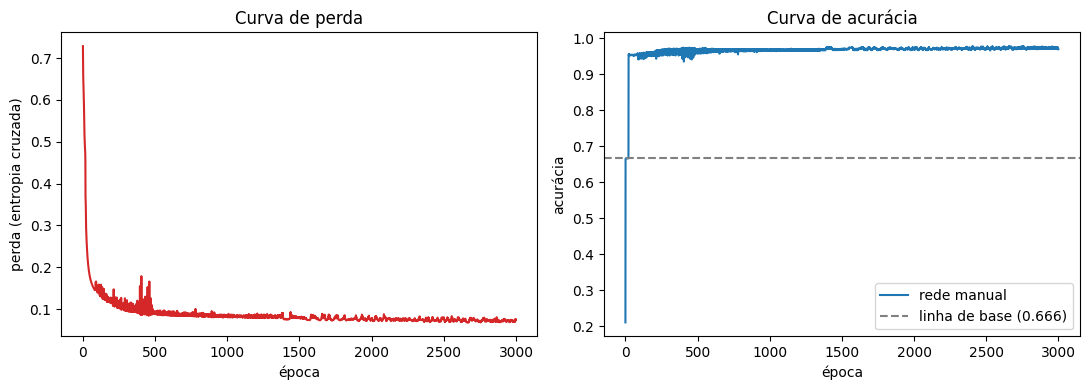

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(historico_perda, color='tab:red')
ax1.set_xlabel('época')
ax1.set_ylabel('perda (entropia cruzada)')
ax1.set_title('Curva de perda')

baseline = max(np.mean(Y == 0), np.mean(Y == 1))
ax2.plot(historico_acc, color='tab:blue', label='rede manual')
ax2.axhline(baseline, color='gray', linestyle='--', label=f'linha de base ({baseline:.3f})')
ax2.set_xlabel('época')
ax2.set_ylabel('acurácia')
ax2.set_title('Curva de acurácia')
ax2.legend()

plt.tight_layout()
plt.savefig('curva_perda_acuracia.png', dpi=150)
plt.show()

## 10. Fronteira de decisão

Como a rede tem só 2 entradas, dá pra desenhar a região que ela classifica como positiva por cima dos
pontos reais.

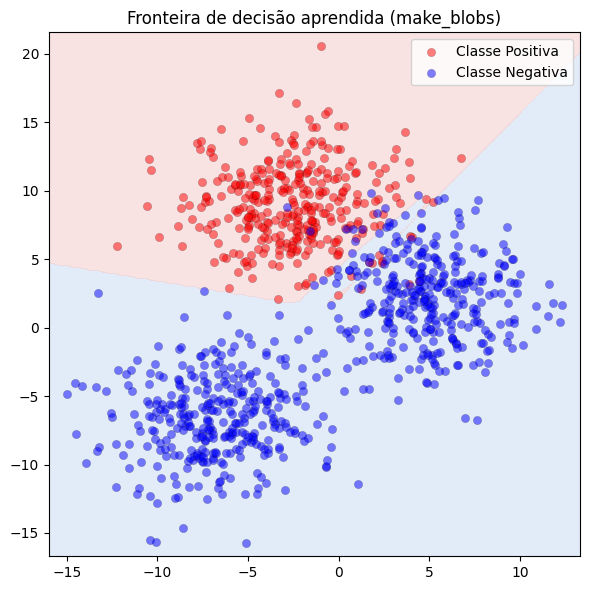

In [11]:
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200),
    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200),
)
grid = np.c_[xx.ravel(), yy.ravel()]
preds_grid, _, _ = forward(grid, W, b)
preds_grid = preds_grid.reshape(xx.shape)

plt.figure(figsize=(6, 6))
plt.contourf(xx, yy, preds_grid, levels=[0, 0.5, 1], colors=['#cfe0f5', '#f5cfcf'], alpha=0.6)
plt.scatter(X[Y.ravel() == 1, 0], X[Y.ravel() == 1, 1], c='red', alpha=0.5, label='Classe Positiva', edgecolor='k', linewidth=0.2)
plt.scatter(X[Y.ravel() == 0, 0], X[Y.ravel() == 0, 1], c='blue', alpha=0.5, label='Classe Negativa', edgecolor='k', linewidth=0.2)
plt.legend(loc='upper right')
plt.title('Fronteira de decisão aprendida (make_blobs)')
plt.tight_layout()
plt.savefig('fronteira_decisao.png', dpi=150)
plt.show()

## 11. Validação com Keras

Mesma arquitetura e mesma perda, agora no Keras, pra ver se os resultados batem com os da rede manual.

Um detalhe: aqui usamos o otimizador Adam, não o mesmo gradiente descendente da Seção 8. Testamos com o
mesmo jeito de antes e o Keras travava sem aprender nada, ficava preso perto da linha de base. Com o Adam
treinou normal. Isso não muda o que a gente quer checar aqui, que é se a arquitetura e a perda estão
certas — não qual otimizador é melhor.

I0000 00:00:1790170696.582767    6849 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790170696.584781    6849 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790170697.187309    6849 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1790170699.988438    6849 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790170699.990297    6849 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


E0000 00:00:1790170700.608661    6849 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Keras -> perda: 0.0762   acurácia: 0.9710
Rede manual (Seção 8) -> perda: 0.0744   acurácia: 0.9730


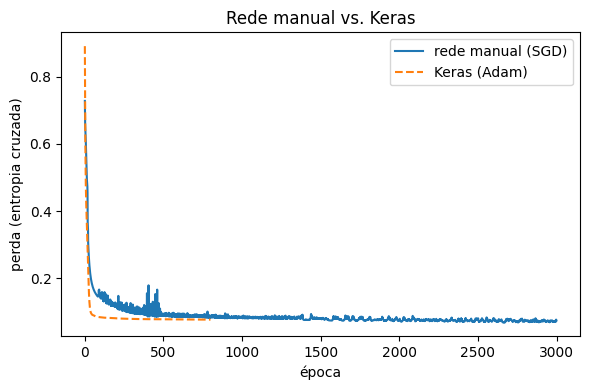

In [12]:
import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

EPOCAS_KERAS = 800

modelo = Sequential([
    Input(shape=(2,)),
    Dense(8, activation='relu'),
    Dense(6, activation='relu'),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid'),
])

modelo.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

historico_keras = modelo.fit(X, Y, epochs=EPOCAS_KERAS, batch_size=len(X), verbose=0)

perda_keras, acc_keras = modelo.evaluate(X, Y, verbose=0)
print(f'Keras -> perda: {perda_keras:.4f}   acurácia: {acc_keras:.4f}')
print(f'Rede manual (Seção 8) -> perda: {perda(Y, yhat_final):.4f}   acurácia: {acuracia(Y, yhat_final):.4f}')

plt.figure(figsize=(6, 4))
plt.plot(historico_perda, label='rede manual (SGD)')
plt.plot(historico_keras.history['loss'], label='Keras (Adam)', linestyle='--')
plt.xlabel('época')
plt.ylabel('perda (entropia cruzada)')
plt.title('Rede manual vs. Keras')
plt.legend()
plt.tight_layout()
plt.savefig('comparacao_keras.png', dpi=150)
plt.show()

## 12. Conclusão

O `exemplo4.py` original era uma rede pequena: 1 camada oculta com 2 neurônios, sigmoide em tudo, erro
quadrático, base `make_moons`. Aqui a gente generalizou essa rede pra funcionar com qualquer número de
camadas, escrevendo tudo em matriz em vez de uma linha por neurônio, com a arquitetura $[2, 8, 6, 4, 1]$
e ReLU nas camadas escondidas.

Trocamos também o erro quadrático pela entropia cruzada, que evita que a rede trave quando erra com
confiança, e conferimos o `backward` com a verificação numérica do gradiente — deu certo, o erro ficou
bem menor que o limite considerado aceitável. A base de dados virou `make_blobs`, desbalanceada de
propósito.

No fim, treinamos a rede manual e comparamos com uma equivalente feita no Keras: as duas chegaram em
valores de perda e acurácia bem parecidos, o que dá confiança de que a implementação está correta.